# Tunisia Telecom Churn Prediction

End-to-end churn prediction workflow: data cleaning, EDA, modeling, and explainability.

## 1. Import Libraries

In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, accuracy_score, roc_auc_score, roc_curve
)
from xgboost import XGBClassifier, plot_importance
import shap
import joblib

sns.set_style("whitegrid")

## 2. Load Dataset

In [44]:
df = pd.read_csv('../data/telco_churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Cleaning

`TotalCharges` is stored as text and has 11 blank rows. We verified these all correspond to
customers with `tenure == 0` (brand-new customers who haven't been billed yet), so filling
with 0 is the correct, equivalent choice (same result as filtering on `tenure == 0`).

In [45]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges:", df['TotalCharges'].isna().sum())

# Confirm every missing TotalCharges row has tenure == 0
print("All missing rows have tenure==0:", (df[df['TotalCharges'].isna()]['tenure'] == 0).all())

Missing TotalCharges: 11
All missing rows have tenure==0: True


In [46]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("Missing after fill:", df['TotalCharges'].isna().sum())
df.info()

Missing after fill: 0
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null

## 4. Exploratory Data Analysis

### 4.1 Class balance — is churn imbalanced?

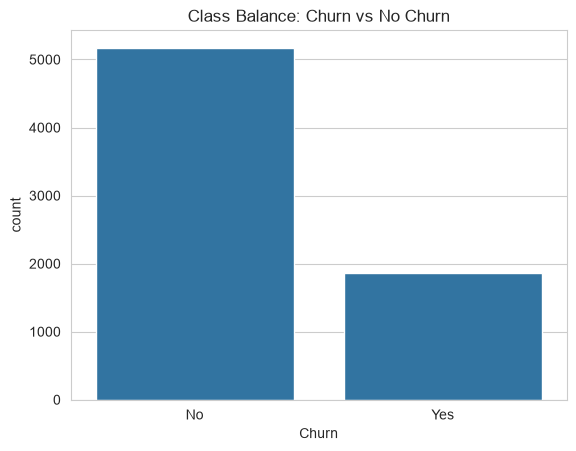

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


In [47]:
sns.countplot(x='Churn', data=df)
plt.title('Class Balance: Churn vs No Churn')
plt.show()

print(df['Churn'].value_counts(normalize=True).round(3))

### 4.2 Churn by Contract Type

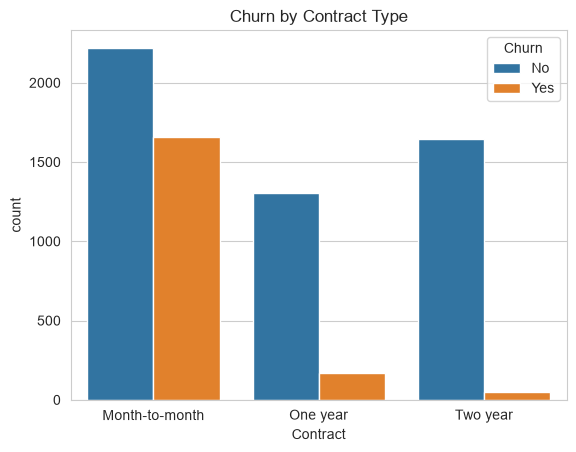

In [48]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.show()

### 4.3 Churn by Tenure

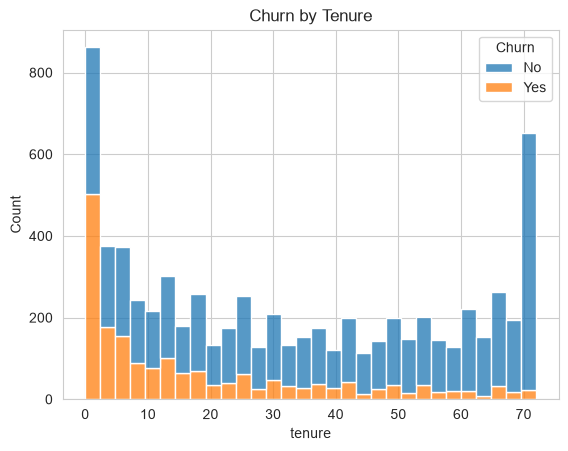

In [49]:
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Churn by Tenure')
plt.show()

### 4.4 Churn by Monthly Charges

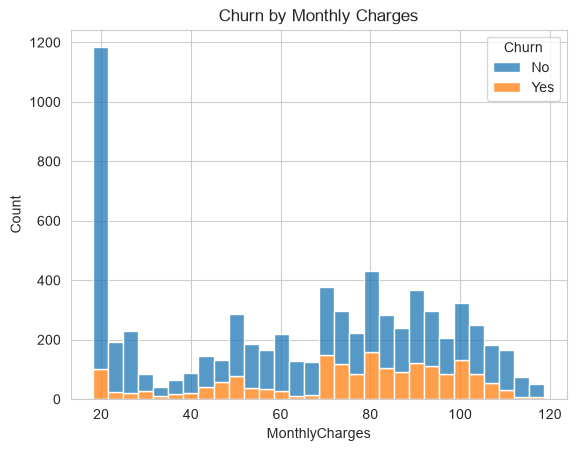

In [50]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', bins=30)
plt.title('Churn by Monthly Charges')
plt.show()

### 4.5 Boxplots — spread of charges by churn status

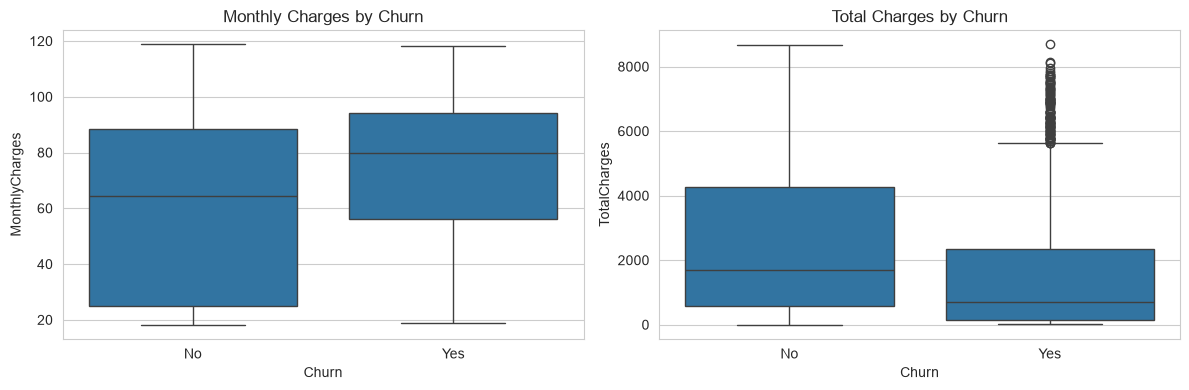

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[0])
axes[0].set_title('Monthly Charges by Churn')
sns.boxplot(x='Churn', y='TotalCharges', data=df, ax=axes[1])
axes[1].set_title('Total Charges by Churn')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [52]:
df_model = df.drop('customerID', axis=1)
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})
df_model = pd.get_dummies(df_model, drop_first=True)

print(df_model.shape)
df_model.head()

(7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


### 5.1 Correlation heatmap (top features vs Churn)

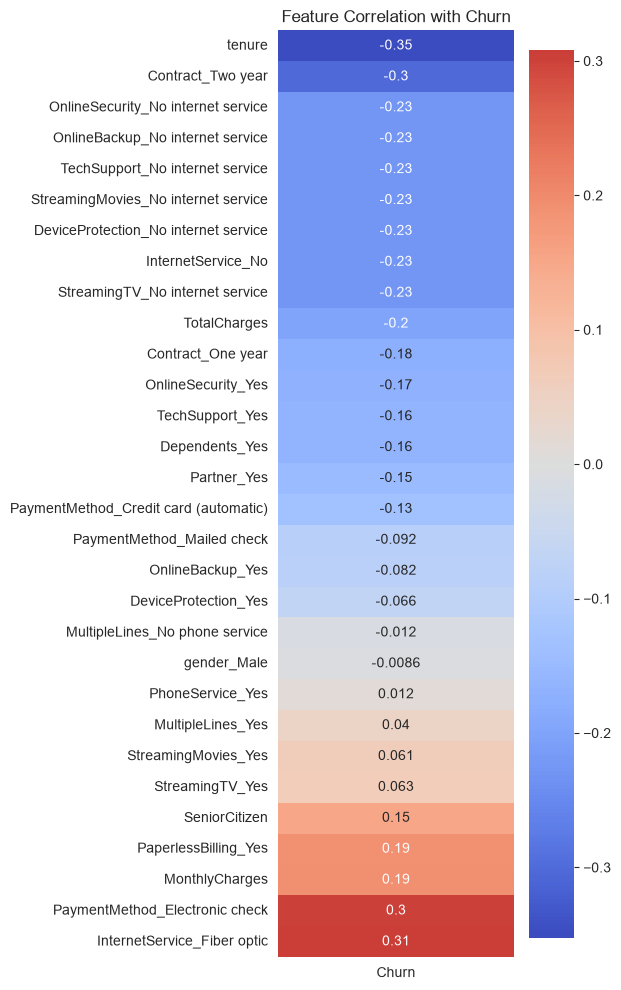

In [53]:
plt.figure(figsize=(6, 10))
corr_with_churn = df_model.corr()['Churn'].drop('Churn').sort_values()
sns.heatmap(corr_with_churn.to_frame(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation with Churn')
plt.tight_layout()
plt.show()

## 6. Train/Test Split

In [54]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(5634, 30) (1409, 30)


## 7. Logistic Regression (Baseline)

Uses a `Pipeline` to bundle scaling + model together (best practice — avoids leakage and
keeps preprocessing attached to the model). `liblinear` solver avoids the convergence
warning we saw with `lbfgs` on unscaled-then-scaled data.

In [55]:
log_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42))
])

log_pipeline.fit(X_train, y_train)
y_pred_log = log_pipeline.predict(X_test)
y_proba_log = log_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))
print()
print(classification_report(y_test, y_pred_log))

Accuracy: 0.7402413058907026
ROC-AUC: 0.84133922343641

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## 8. XGBoost

Trees don't need feature scaling, so we use the raw `X_train` (not the scaled version) here.

In [56]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print()
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7572746628814763
ROC-AUC: 0.8366232659071533

              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1035
           1       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



## 9. Model Comparison

In [57]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_xgb)],
    'ROC-AUC': [roc_auc_score(y_test, y_proba_log), roc_auc_score(y_test, y_proba_xgb)],
})
comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.740241,0.841339
1,XGBoost,0.757275,0.836623


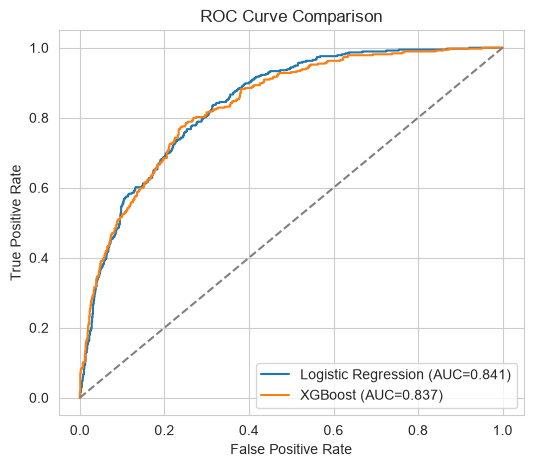

In [58]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(6, 5))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_proba_log):.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={roc_auc_score(y_test, y_proba_xgb):.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

**Decision: XGBoost is the final model** — slightly better accuracy and ROC-AUC than Logistic Regression, with comparable recall on churners.

## 10. Feature Importance (XGBoost built-in)

<Figure size 800x600 with 0 Axes>

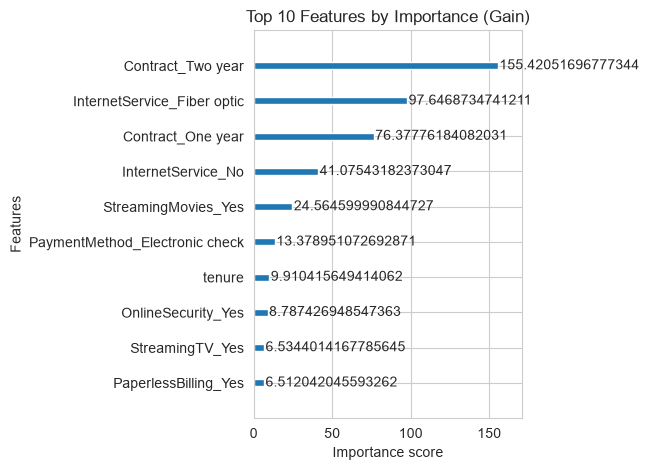

In [59]:
plt.figure(figsize=(8, 6))
plot_importance(xgb_model, max_num_features=10, importance_type='gain')
plt.title('Top 10 Features by Importance (Gain)')
plt.tight_layout()
plt.show()

## 11. SHAP Explainability

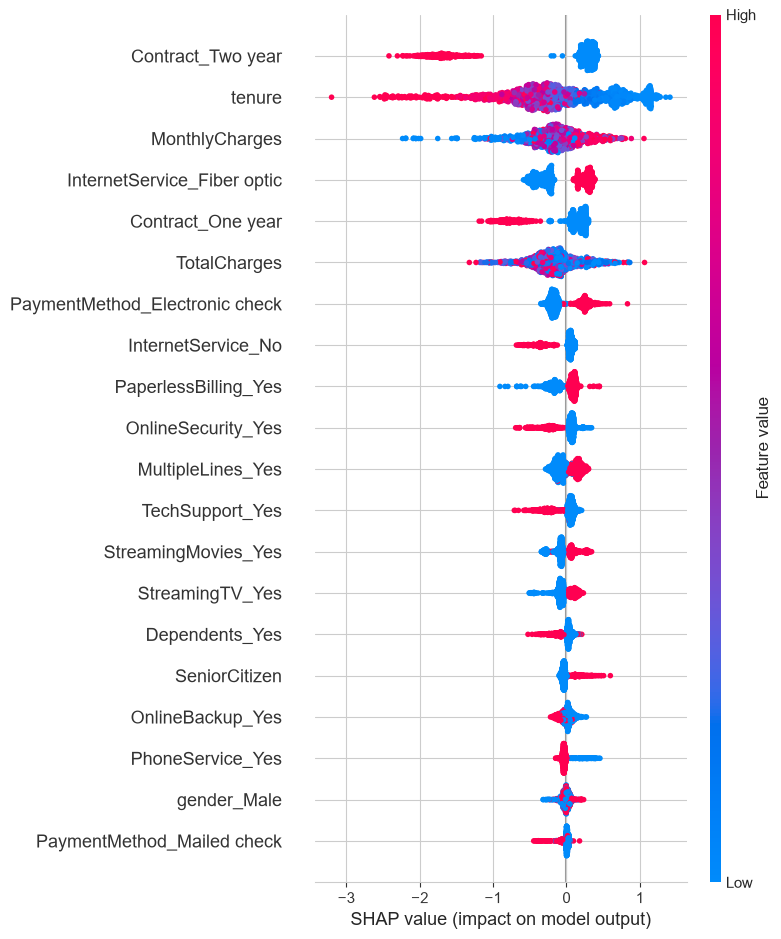

In [60]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

### 11.1 Individual customer explanation examples

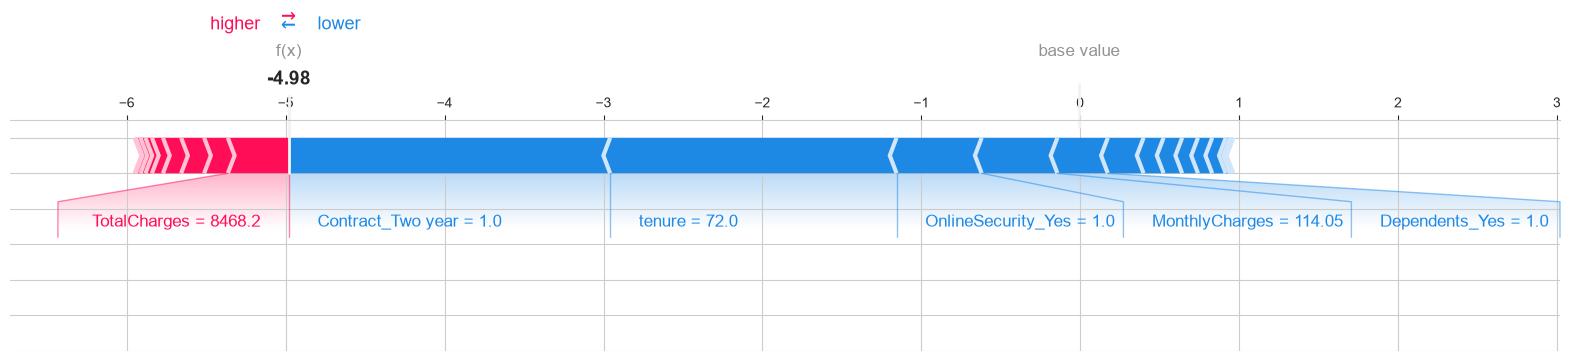

In [61]:
# Example: a stable, low-risk customer
idx = 0
shap.force_plot(explainer.expected_value, shap_values[idx], X_test.iloc[idx], matplotlib=True)

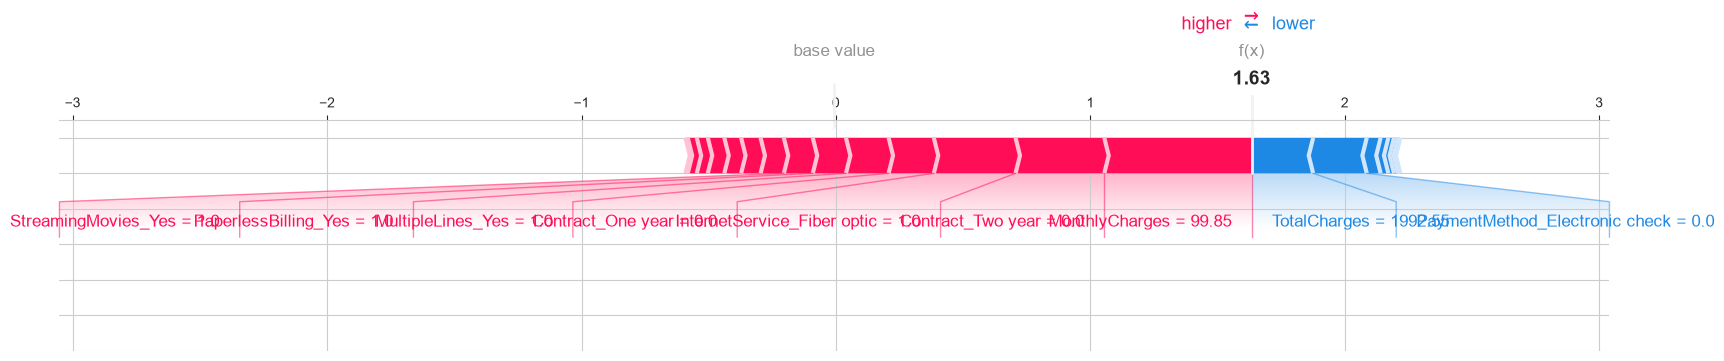

In [62]:
# Example: a high-risk customer
idx = 5
shap.force_plot(explainer.expected_value, shap_values[idx], X_test.iloc[idx], matplotlib=True)

## 12. Save Model

In [63]:
joblib.dump(xgb_model, '../src/churn_model.pkl')
joblib.dump(list(X_train.columns), '../src/model_columns.pkl')
print("Model and columns saved.")

Model and columns saved.


## Known Limitations

- **Rare-tenure edge cases**: only 11 of 7,043 customers have `tenure == 0`, so predictions
  for brand-new customers are less reliable.
- **Probability calibration**: because `scale_pos_weight` is used to handle class imbalance,
  high-risk scores tend to be somewhat overconfident (e.g., a predicted 79% risk group has
  an actual churn rate closer to 57%). Treat scores as a relative risk ranking rather than
  an exact probability.
- **Accuracy ceiling**: this is a well-known public benchmark dataset. Published results
  typically top out around 80-82% accuracy; pushing further generally sacrifices recall on
  churners, which defeats the purpose of the tool. This model prioritizes recall (78% on
  churners) over raw accuracy.